#Load libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier

#Loading Data Set

In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
file_path_train = '/content/drive/MyDrive/Project ITI/aug_train.csv'
file_path_test = '/content/drive/MyDrive/Project ITI/aug_test.csv'

In [62]:
df_train = pd.read_csv(file_path_train)
df_test = pd.read_csv(file_path_test)

display(df_train.head())
display(df_test.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


#EDA

In [63]:
df_train.shape

(19158, 14)

In [64]:
#data types of dataset
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [65]:
#check for missing values
df_train.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


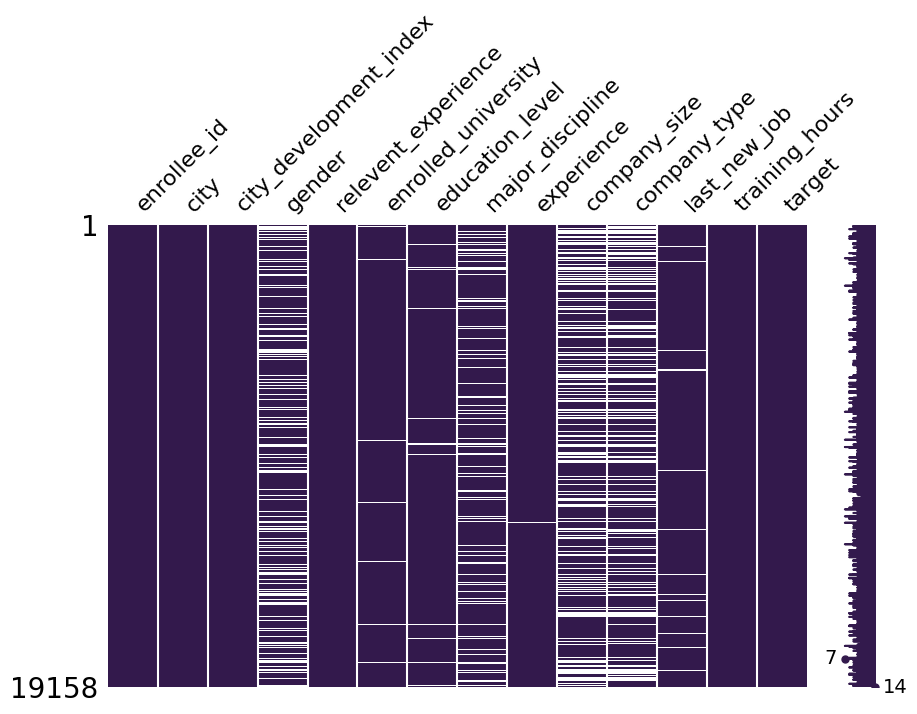

In [66]:
#Show the distribution of missing values
#Plot the matrix
msno.matrix(df_train, figsize=(10, 6), color=(0.2, 0.1, 0.3))
plt.show()

In [67]:

# Calculate percentage of missing values
null_percentages = (df_train.isnull().sum() / len(df_train)) * 100

# Filter for columns that have missing data and sort them
null_df = null_percentages[null_percentages > 0].sort_values(ascending=False).to_frame(name='Missing Percentage (%)')

print("--- PERCENTAGE OF NULL VALUES ---")
print(null_df)

--- PERCENTAGE OF NULL VALUES ---
                     Missing Percentage (%)
company_type                      32.049274
company_size                      30.994885
gender                            23.530640
major_discipline                  14.683161
education_level                    2.401086
last_new_job                       2.207955
enrolled_university                2.014824
experience                         0.339284


In [68]:
# check for duplicates
df_train.duplicated().sum()

np.int64(0)

In [69]:
print("\n--- STATISTICS (NUMERICAL) ---")
print(df_train.describe())

#View statistics for categorical/text columns
print("\n--- STATISTICS (CATEGORICAL) ---")
print(df_train.describe(include=['object']))


--- STATISTICS (NUMERICAL) ---
        enrollee_id  city_development_index  training_hours        target
count  19158.000000            19158.000000    19158.000000  19158.000000
mean   16875.358179                0.828848       65.366896      0.249348
std     9616.292592                0.123362       60.058462      0.432647
min        1.000000                0.448000        1.000000      0.000000
25%     8554.250000                0.740000       23.000000      0.000000
50%    16982.500000                0.903000       47.000000      0.000000
75%    25169.750000                0.920000       88.000000      0.000000
max    33380.000000                0.949000      336.000000      1.000000

--- STATISTICS (CATEGORICAL) ---
            city gender      relevent_experience enrolled_university  \
count      19158  14650                    19158               18772   
unique       123      3                        2                   3   
top     city_103   Male  Has relevent experience    

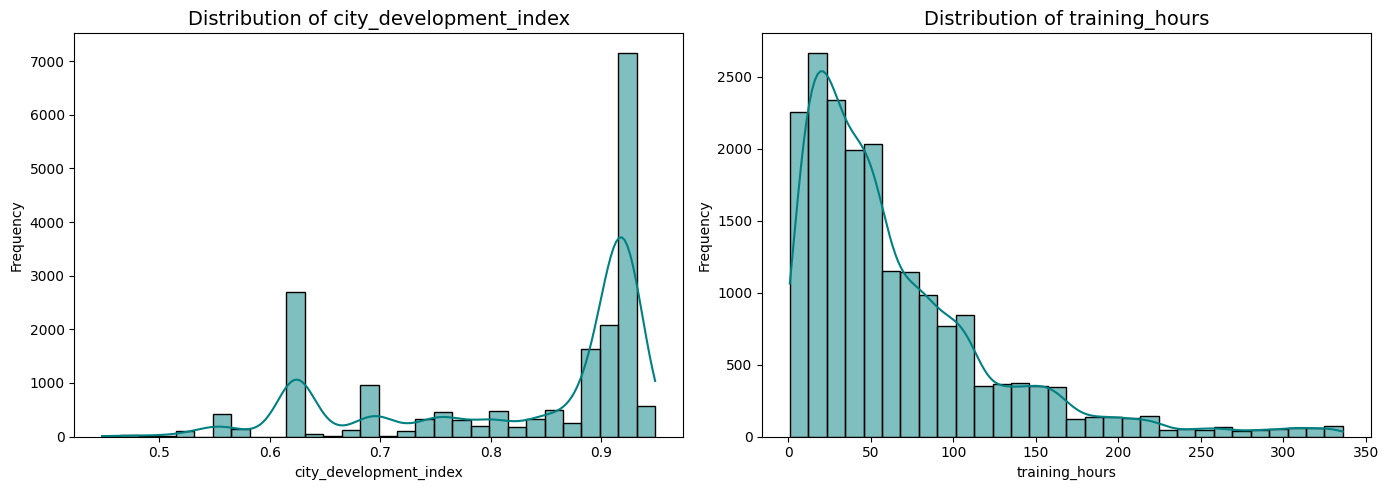

In [70]:
#Distribution of Numerical Columns
num_cols = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df_train[col], kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()

plt.show()


/tmp/ipykernel_474/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_474/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_474/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
/tmp/ipykernel_474/3991473812.py:10: FutureWarning: 

Passing `palette` without assigning `hue

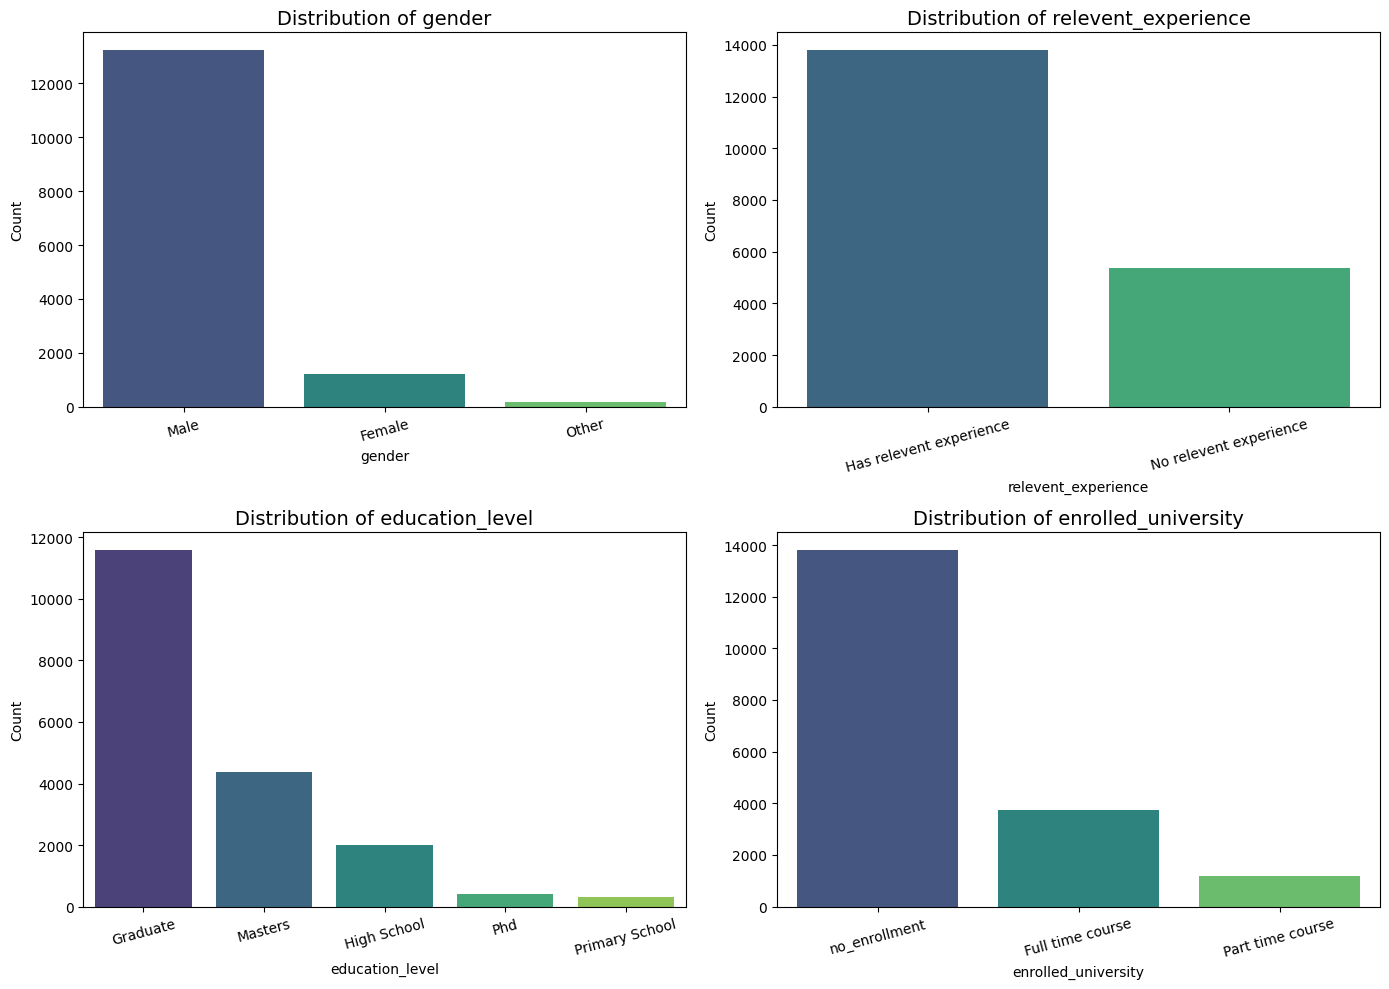

In [71]:
#Distribution of Categorical Columns
cat_cols = ['gender', 'relevent_experience', 'education_level', 'enrolled_university']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Order the bars by count for better readability
    order = df_train[col].value_counts().index
    sns.countplot(data=df_train, x=col, ax=axes[i], palette='viridis', order=order)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()

plt.show()

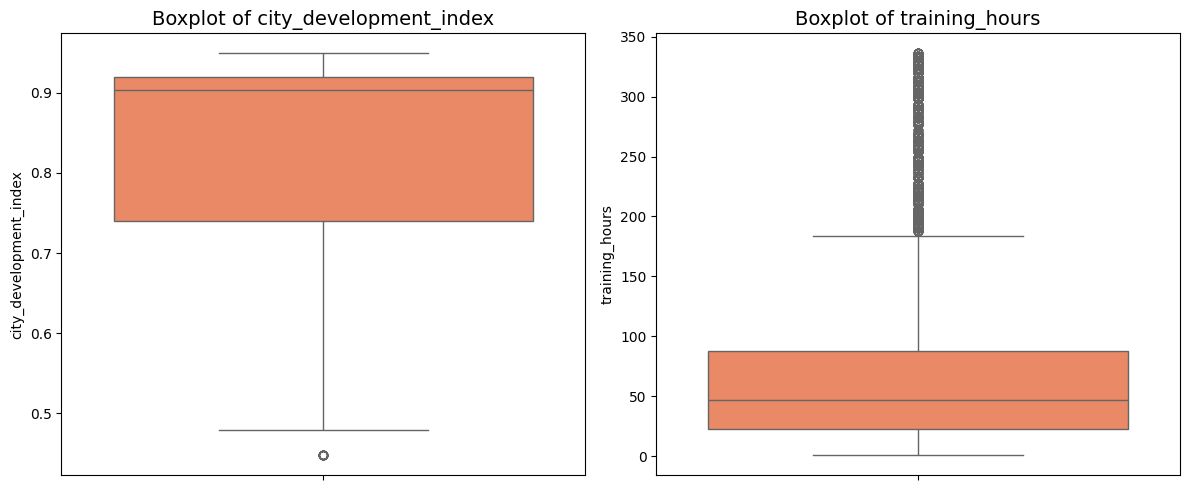

--- OUTLIER DETECTION (IQR METHOD) ---
city_development_index:
  - Number of Outliers: 17
  - Bounds: Lower 0.470, Upper 1.190
  - Percentage: 0.09%

training_hours:
  - Number of Outliers: 984
  - Bounds: Lower -74.500, Upper 185.500
  - Percentage: 5.14%



In [72]:

num_cols = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df_train[col], ax=axes[i], color='coral')
    axes[i].set_title(f'Boxplot of {col}', fontsize=14)

plt.tight_layout()
plt.savefig('outliers_boxplot.png')
plt.show()

#Calculating Outliers using IQR Method
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1


    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("--- OUTLIER DETECTION (IQR METHOD) ---")
for col in num_cols:
    num_outliers, lower, upper = count_outliers(df_train[col])
    print(f"{col}:")
    print(f"  - Number of Outliers: {num_outliers}")
    print(f"  - Bounds: Lower {lower:.3f}, Upper {upper:.3f}")
    print(f"  - Percentage: {(num_outliers / len(df_train)) * 100:.2f}%\n")

/tmp/ipykernel_474/4209397134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')
/tmp/ipykernel_474/4209397134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')
/tmp/ipykernel_474/4209397134.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')


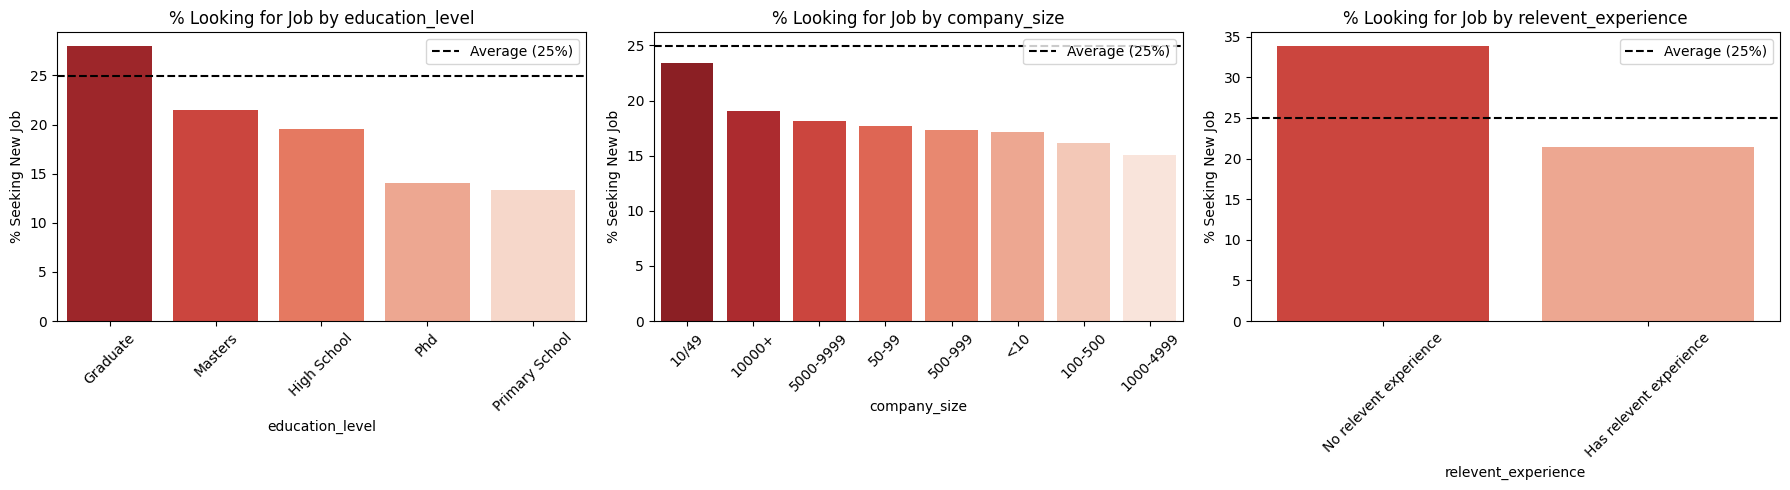

In [73]:
#Bivariate Analysis: Target vs Categorical Features
features_to_check = ['education_level', 'company_size', 'relevent_experience']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_to_check):
    # Calculate percentage of target=1 for each category
    target_pct = df_train.groupby(col)['target'].mean().sort_values(ascending=False) * 100

    sns.barplot(x=target_pct.index, y=target_pct.values, ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'% Looking for Job by {col}', fontsize=12)
    axes[i].set_ylabel('% Seeking New Job')
    axes[i].tick_params(axis='x', rotation=45)

    # Add horizontal line for dataset average
    axes[i].axhline(df_train['target'].mean() * 100, color='black', linestyle='--', label='Average (25%)')
    axes[i].legend()

plt.tight_layout()
plt.show()

#Preprocessing

In [74]:
df_train.fillna("Unknown", inplace=True)
df_test.fillna("Unknown", inplace=True)


Handling missing values

In [75]:
print("Missing values in Train data after cleaning:", df_train.isnull().sum().sum())
print("Missing values in Train data after cleaning:", df_test.isnull().sum().sum())

Missing values in Train data after cleaning: 0
Missing values in Train data after cleaning: 0


Handling Outliers

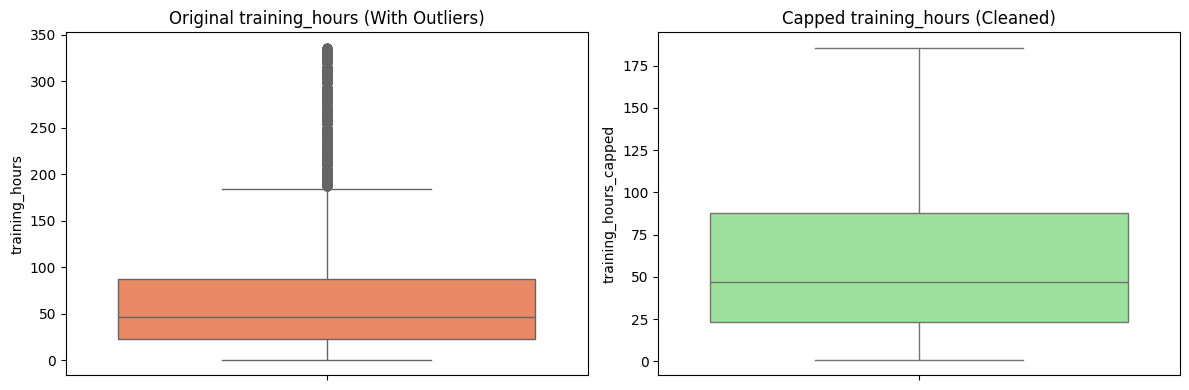

In [76]:
#Handle Outliers in training_hours
Q1 = df_train['training_hours'].quantile(0.25)
Q3 = df_train['training_hours'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR


df_train['training_hours_capped'] = df_train['training_hours'].clip(upper=upper_bound)


df_test['training_hours_capped'] = df_test['training_hours'].clip(upper=upper_bound)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_train['training_hours'], ax=axes[0], color='coral')
axes[0].set_title('Original training_hours (With Outliers)')

sns.boxplot(y=df_train['training_hours_capped'], ax=axes[1], color='lightgreen')
axes[1].set_title('Capped training_hours (Cleaned)')

plt.tight_layout()
plt.show()

#Encoding

In [77]:

#Education level Ordinal Encoding
education_level_mapping = {
    'Unknown': -1,
    'Primary School': 0,
    'High School': 1,
    'Graduate': 2,
    'Masters': 3,
    'Phd': 4
}


df_train['education_level_encoded'] = df_train['education_level'].map(education_level_mapping)
df_test['education_level_encoded'] = df_test['education_level'].map(education_level_mapping)

In [78]:
#Relevant experience Ordinal Encoding
relevent_experience_mapping = {
    'No relevent experience': 0,
    'Has relevent experience': 1
}

df_train['relevent_experience_encoded'] = df_train['relevent_experience'].map(relevent_experience_mapping)
df_test['relevent_experience_encoded'] = df_test['relevent_experience'].map(relevent_experience_mapping)

In [79]:
#Experience Ordinal Encoding
experience_mapping = {
    'Unknown': -1,
    '<1': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '5': 5,
    '6': 6,
    '7': 7,
    '8': 8,
    '9': 9,
    '10': 10,
    '11': 11,
    '12': 12,
    '13': 13,
    '14': 14,
    '15': 15,
    '16': 16,
    '17': 17,
    '18': 18,
    '19': 19,
    '20': 20,
    '>20': 21,
}

df_train['experience_encoded'] = df_train['experience'].map(experience_mapping).fillna(0)
df_test['experience_encoded'] = df_test['experience'].map(experience_mapping).fillna(0)

In [80]:
#Company size Ordinal Encoding
company_size_mapping = {
    'Unknown': -1,
    '<10': 0,
    '10-49': 1,
    '10/49': 1,
    '50-99': 2,
    '100-500': 3,
    '500-999': 4,
    '1000-4999': 5,
    '5000-9999': 6,
    '10000+': 7
}

df_train['company_size_encoded'] = df_train['company_size'].map(company_size_mapping)
df_test['company_size_encoded'] = df_test['company_size'].map(company_size_mapping)

In [81]:
#LNJ Ordinal Encoding
last_new_job_mapping = {
    'Unknown': -1,
    'never': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '>4': 5
}

df_train['last_new_job_encoded'] = df_train['last_new_job'].map(last_new_job_mapping).fillna(0)
df_test['last_new_job_encoded'] = df_test['last_new_job'].map(last_new_job_mapping).fillna(0)

In [82]:
#Enrolled Uni Ordinal Encoding
enrolled_university_mapping = {
    'Unknown': -1 ,
    'no_enrollment': 0,
    'Full time course': 1,
    'Part time course': 2


}

df_train['enrolled_university_encoded'] = df_train['enrolled_university'].map(enrolled_university_mapping)
df_test['enrolled_university_encoded'] = df_test['enrolled_university'].map(enrolled_university_mapping)

In [83]:
display(df_train.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,...,last_new_job,training_hours,target,training_hours_capped,education_level_encoded,relevent_experience_encoded,experience_encoded,company_size_encoded,last_new_job_encoded,enrolled_university_encoded
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,...,1,36,1.0,36.0,2,1,21,-1,1.0,0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,...,>4,47,0.0,47.0,2,0,15,2,5.0,0
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,...,never,83,0.0,83.0,2,0,5,-1,0.0,1
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,...,never,52,1.0,52.0,2,0,0,-1,0.0,-1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,...,4,8,0.0,8.0,3,1,21,2,0.0,0


In [84]:
#City Frequency Encoding
city_freq_map = df_train['city'].value_counts(normalize=True).to_dict()


df_train['city_freq'] = df_train['city'].map(city_freq_map)
df_test['city_freq'] = df_test['city'].map(city_freq_map).fillna(0)

train = df_train.drop(columns=['city'])
test = df_test.drop(columns=['city'])

In [85]:
#major_discipline One Hot Encoding
major_discipline_dummies_train = pd.get_dummies(df_train['major_discipline'], prefix='major_discipline')
major_discipline_dummies_test = pd.get_dummies(df_test['major_discipline'], prefix='major_discipline')

train_cols = major_discipline_dummies_train.columns
test_cols = major_discipline_dummies_test.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    major_discipline_dummies_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    major_discipline_dummies_train[c] = 0

major_discipline_dummies_test = major_discipline_dummies_test[train_cols]

df_train = pd.concat([df_train, major_discipline_dummies_train], axis=1)
df_test = pd.concat([df_test, major_discipline_dummies_test], axis=1)

df_train.drop(columns=['major_discipline'], inplace=True)
df_test.drop(columns=['major_discipline'], inplace=True)

In [86]:
display(df_train.head())

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,experience,company_size,company_type,...,last_new_job_encoded,enrolled_university_encoded,city_freq,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,>20,Unknown,Unknown,...,1.0,0,0.227320,False,False,False,False,False,True,False
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,15,50-99,Pvt Ltd,...,5.0,0,0.003549,False,False,False,False,False,True,False
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,5,Unknown,Unknown,...,0.0,1,0.141038,False,False,False,False,False,True,False
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,<1,Unknown,Pvt Ltd,...,0.0,-1,0.002819,False,True,False,False,False,False,False
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,>20,50-99,Funded Startup,...,0.0,0,0.006681,False,False,False,False,False,True,False


In [87]:
#Gender One Hot Encoding
gender_dummies_train = pd.get_dummies(df_train['gender'], prefix='gender')
gender_dummies_test = pd.get_dummies(df_test['gender'], prefix='gender')


train_cols_gender = gender_dummies_train.columns
test_cols_gender = gender_dummies_test.columns

missing_in_test_gender = set(train_cols_gender) - set(test_cols_gender)
for c in missing_in_test_gender:
    gender_dummies_test[c] = 0

missing_in_train_gender = set(test_cols_gender) - set(train_cols_gender)
for c in missing_in_train_gender:
    gender_dummies_train[c] = 0

gender_dummies_test = gender_dummies_test[train_cols_gender]

df_train = pd.concat([df_train, gender_dummies_train], axis=1)
df_test = pd.concat([df_test, gender_dummies_test], axis=1)

df_train.drop(columns=['gender'], inplace=True)
df_test.drop(columns=['gender'], inplace=True)

In [88]:
display(df_train.head())

,enrollee_id,city,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,company_type,last_new_job,...,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_Unknown,gender_Female,gender_Male,gender_Other,gender_Unknown
0,8949,city_103,0.920,Has relevent experience,no_enrollment,Graduate,>20,Unknown,Unknown,1,...,False,False,False,False,True,False,False,True,False,False
1,29725,city_40,0.776,No relevent experience,no_enrollment,Graduate,15,50-99,Pvt Ltd,>4,...,False,False,False,False,True,False,False,True,False,False
2,11561,city_21,0.624,No relevent experience,Full time course,Graduate,5,Unknown,Unknown,never,...,False,False,False,False,True,False,False,False,False,True
3,33241,city_115,0.789,No relevent experience,Unknown,Graduate,<1,Unknown,Pvt Ltd,never,...,True,False,False,False,False,False,False,False,False,True
4,666,city_162,0.767,Has relevent experience,no_enrollment,Masters,>20,50-99,Funded Startup,4,...,False,False,False,False,True,False,False,True,False,False


In [89]:
#Company type One Hot Encoding
company_type_dummies_train = pd.get_dummies(df_train['company_type'], prefix='company_type')
company_type_dummies_test = pd.get_dummies(df_test['company_type'], prefix='company_type')

train_cols_company_type = company_type_dummies_train.columns
test_cols_company_type = company_type_dummies_test.columns

missing_in_test_company_type = set(train_cols_company_type) - set(test_cols_company_type)
for c in missing_in_test_company_type:
    company_type_dummies_test[c] = 0

missing_in_train_company_type = set(test_cols_company_type) - set(train_cols_company_type)
for c in missing_in_train_company_type:
    company_type_dummies_train[c] = 0

company_type_dummies_test = company_type_dummies_test[train_cols_company_type]

df_train = pd.concat([df_train, company_type_dummies_train], axis=1)
df_test = pd.concat([df_test, company_type_dummies_test], axis=1)

df_train.drop(columns=['company_type'], inplace=True)
df_test.drop(columns=['company_type'], inplace=True)

In [90]:
display(df_train.head())

,enrollee_id,city,city_development_index,relevent_experience,enrolled_university,education_level,experience,company_size,last_new_job,training_hours,...,gender_Male,gender_Other,gender_Unknown,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_Unknown
0,8949,city_103,0.920,Has relevent experience,no_enrollment,Graduate,>20,Unknown,1,36,...,True,False,False,False,False,False,False,False,False,True
1,29725,city_40,0.776,No relevent experience,no_enrollment,Graduate,15,50-99,>4,47,...,True,False,False,False,False,False,False,False,True,False
2,11561,city_21,0.624,No relevent experience,Full time course,Graduate,5,Unknown,never,83,...,False,False,True,False,False,False,False,False,False,True
3,33241,city_115,0.789,No relevent experience,Unknown,Graduate,<1,Unknown,never,52,...,False,False,True,False,False,False,False,False,True,False
4,666,city_162,0.767,Has relevent experience,no_enrollment,Masters,>20,50-99,4,8,...,True,False,False,False,True,False,False,False,False,False


#Modeling

In [91]:
from sklearn.inspection import permutation_importance

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cols_to_drop_train = [
    'target',
    'enrollee_id',
    'city',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'experience',
    'company_size',
    'last_new_job',
    'training_hours'
]

cols_to_drop_test = [
    'enrollee_id',
    'city',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'experience',
    'company_size',
    'last_new_job',
    'training_hours'
]

X_train = df_train.drop(columns=cols_to_drop_train)
X_test = df_test.drop(columns=cols_to_drop_test)
y_train = df_train['target']

X_train = X_train.select_dtypes(include=np.number)
X_test = X_test.select_dtypes(include=np.number)

X_test = X_test[X_train.columns]


#Logistic Regression

In [116]:
from sklearn.feature_selection import SelectFromModel

rf_for_selection = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
feature_selector = SelectFromModel(rf_for_selection, threshold='median')

logreg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', feature_selector),
    ('model', logreg) ])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Evaluating model with feature selection...")
scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
print(f"CV ROC-AUC Score: {scores.mean():.4f} +/- {scores.std():.4f}")

y_pred_cv = cross_val_predict(pipeline, X_train, y_train, cv=cv)



Evaluating model with feature selection...
CV ROC-AUC Score: 0.7615 +/- 0.0041


In [117]:
# 1. Classification Report for Logistic Regression
print("\n--- Cross-Validated Classification Report ---")
print(classification_report(y_train, y_pred_cv))


--- Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.88      0.75      0.81     14381
         1.0       0.48      0.69      0.56      4777

    accuracy                           0.73     19158
   macro avg       0.68      0.72      0.69     19158
weighted avg       0.78      0.73      0.75     19158



#Random Forest Model

In [94]:
#Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100,  class_weight='balanced', random_state=42, n_jobs=-1)


rf_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Random Forest CV ROC-AUC: {rf_scores.mean():.4f} +/- {rf_scores.std():.4f}")

results['Random Forest'] = {'cv_auc_mean': rf_scores.mean(), 'cv_auc_std': rf_scores.std()}


y_pred_cv_rf = cross_val_predict(rf_model, X_train, y_train, cv=cv)

print("\n--- Random Forest Cross-Validated Classification Report ---")

print(classification_report(y_train, y_pred_cv_rf))

Random Forest CV ROC-AUC: 0.7835 +/- 0.0050

--- Random Forest Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86     14381
         1.0       0.57      0.45      0.50      4777

    accuracy                           0.78     19158
   macro avg       0.70      0.67      0.68     19158
weighted avg       0.76      0.78      0.77     19158



#Random Forest Hyperparameter Tuning

In [95]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=10,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)
print(f"Best RF Params: {rf_random.best_params_}")
print(f"Best RF CV ROC-AUC: {rf_random.best_score_:.4f}")


results['Random Forest (Tuned)'] = {'cv_auc_mean': rf_random.best_score_, 'cv_auc_std': rf_random.cv_results_['std_test_score'][rf_random.best_index_]}

Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
Best RF CV ROC-AUC: 0.8008


In [96]:
# 1. Classification Report for Tuned Random Forest
y_pred_cv_rf_tuned = cross_val_predict(rf_random.best_estimator_, X_train, y_train, cv=cv)
print("Tuned Random Forest Cross-Validated Classification Report")
print(classification_report(y_train, y_pred_cv_rf_tuned))

Tuned Random Forest Cross-Validated Classification Report
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56      0.72      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158



#XGBOOST

In [97]:
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}")

Calculated Imbalance Ratio: 3.01


In [109]:

imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Calculated Imbalance Ratio: {imbalance_ratio:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=imbalance_ratio,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb_model)
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\nEvaluating XGBoost model...")
xgb_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"XGBoost CV ROC-AUC Score: {xgb_scores.mean():.4f} +/- {xgb_scores.std():.4f}")

results['XGBoost'] = {'cv_auc_mean': xgb_scores.mean(), 'cv_auc_std': xgb_scores.std()}
y_pred_cv_xgb = cross_val_predict(xgb_pipeline, X_train, y_train, cv=cv)


Calculated Imbalance Ratio: 3.01

Evaluating XGBoost model...
XGBoost CV ROC-AUC Score: 0.8003 +/- 0.0041


In [110]:
# 1. Classification Report for XGBoost
print("\n--- XGBoost Cross-Validated Classification Report ---")
print(classification_report(y_train, y_pred_cv_xgb))


--- XGBoost Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85     14381
         1.0       0.55      0.74      0.63      4777

    accuracy                           0.78     19158
   macro avg       0.72      0.77      0.74     19158
weighted avg       0.81      0.78      0.79     19158



#XGBoost Hyperparameter Tuning

In [119]:
param_distributions = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.8, 1.0]
}

#Set up the RandomizedSearchCV
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=cv,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)


print("Starting hyperparameter tuning for XGBoost...")
xgb_random_search.fit(X_train, y_train)

best_xgb_pipeline = xgb_random_search.best_estimator_

print("\n--- TUNING RESULTS ---")
print(f"Best Parameters Found:\n{xgb_random_search.best_params_}")
print(f"Best CV ROC-AUC Score: {xgb_random_search.best_score_:.4f}")

# Update your results dictionary
results['Tuned XGBoost'] = {
    'cv_auc_mean': xgb_random_search.best_score_,
    'cv_auc_std': xgb_random_search.cv_results_['std_test_score'][xgb_random_search.best_index_]
}

y_pred_cv_tuned_xgb = cross_val_predict(best_xgb_pipeline, X_train, y_train, cv=cv)

Starting hyperparameter tuning for XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- TUNING RESULTS ---
Best Parameters Found:
{'classifier__subsample': 0.6, 'classifier__n_estimators': 300, 'classifier__max_depth': 8, 'classifier__learning_rate': 0.01, 'classifier__colsample_bytree': 0.6}
Best CV ROC-AUC Score: 0.8031


In [118]:
# 1. Classification Report for Tuned XGBoost
print("\n--- Tuned XGBoost Cross-Validated Classification Report ---")
print(classification_report(y_train, y_pred_cv_tuned_xgb))


--- Tuned XGBoost Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56      0.74      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.82      0.79      0.80     19158



#Ensembling

In [120]:
# Define the individual models (using the best estimators from our tuning)
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', rf_random.best_estimator_),
        ('xgb', xgb_random_search.best_estimator_),
        ('lr', logreg)
    ],
    voting='soft',
    n_jobs=-1
)

# Evaluate the Ensemble using Cross-Validation
print("Evaluating Ensemble Model (RF + XGB + LR)...")
ensemble_scores = cross_val_score(ensemble_model, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"Ensemble CV ROC-AUC Score: {ensemble_scores.mean():.4f} +/- {ensemble_scores.std():.4f}")


results['Ensemble (Voting)'] = {'cv_auc_mean': ensemble_scores.mean(), 'cv_auc_std': ensemble_scores.std()}


y_pred_cv_ensemble = cross_val_predict(ensemble_model, X_train, y_train, cv=cv)

Evaluating Ensemble Model (RF + XGB + LR)...
Ensemble CV ROC-AUC Score: 0.8000 +/- 0.0030

--- Ensemble Cross-Validated Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56      0.73      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158



In [ ]:
# 1. Classification Report for Ensembling
print("\n--- Ensemble Cross-Validated Classification Report ---")
print(classification_report(y_train, y_pred_cv_ensemble))

#Models Evaluation

Running cross-validation for all models. This may take a minute...

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

         0.0       0.89      0.75      0.81     14381
         1.0       0.48      0.71      0.58      4777

    accuracy                           0.74     19158
   macro avg       0.69      0.73      0.69     19158
weighted avg       0.79      0.74      0.75     19158

--- Tuned Random Forest Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56      0.72      0.63      4777

    accuracy                           0.79     19158
   macro avg       0.73      0.77      0.74     19158
weighted avg       0.81      0.79      0.80     19158

--- Tuned XGBoost Classification Report ---
              precision    recall  f1-score   support

         0.0       0.90      0.81      0.85     14381
         1.0       0.56  

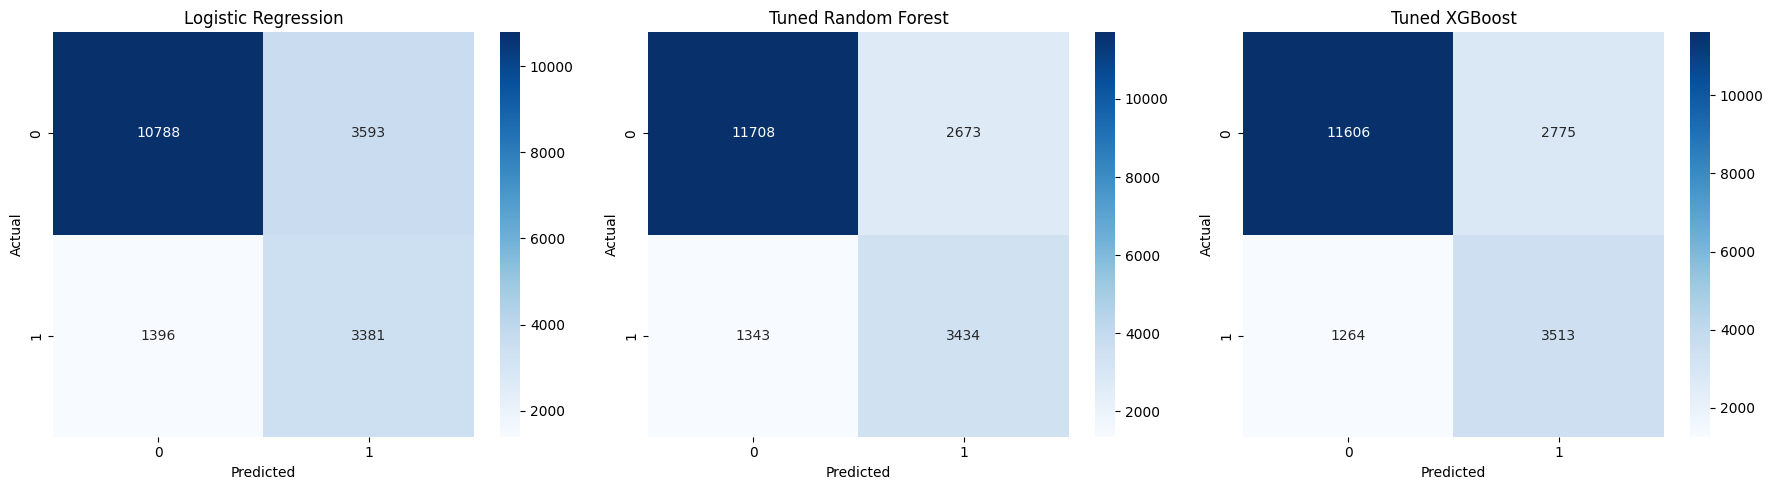

In [121]:
# 1. Define the models you want to compare
models_to_compare = {
    'Logistic Regression': logreg,
    'Tuned Random Forest': rf_random.best_estimator_,
    'Tuned XGBoost': best_xgb_pipeline
}

# 2. Setup plotting for Confusion Matrices
fig, axes = plt.subplots(1, len(models_to_compare), figsize=(18, 5))
comparison_data = []

print("Running cross-validation for all models. This may take a minute...\n")

# 3. Loop through each model to calculate metrics and plot
for i, (model_name, model) in enumerate(models_to_compare.items()):

    # Generate predictions
    y_pred_cv = cross_val_predict(model, X_train, y_train, cv=cv)

    # Generate probabilities for ROC-AUC
    try:
        y_pred_proba_cv = cross_val_predict(model, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
        auc_score = roc_auc_score(y_train, y_pred_proba_cv)
    except:
        auc_score = np.nan

    # Calculate specific metrics for Class 1.0 (People looking for a job)
    recall_1 = recall_score(y_train, y_pred_cv)
    precision_1 = precision_score(y_train, y_pred_cv)
    f1_1 = f1_score(y_train, y_pred_cv)

    # Save to our comparison list
    comparison_data.append({
        'Model': model_name,
        'ROC-AUC': auc_score,
        'Class 1 Recall': recall_1,
        'Class 1 Precision': precision_1,
        'Class 1 F1-Score': f1_1
    })

    # Print Classification Report
    print(f"--- {model_name} Classification Report ---")
    print(classification_report(y_train, y_pred_cv))

    # Plot Confusion Matrix
    sns.heatmap(confusion_matrix(y_train, y_pred_cv), annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{model_name}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.show()


=== MASTER MODEL COMPARISON ===
| Model               |   ROC-AUC |   Class 1 Recall |   Class 1 Precision |   Class 1 F1-Score |
|:--------------------|----------:|-----------------:|--------------------:|-------------------:|
| Tuned XGBoost       |  0.803053 |         0.735399 |            0.558683 |           0.634975 |
| Tuned Random Forest |  0.800597 |         0.718861 |            0.562306 |           0.631018 |
| Logistic Regression |  0.770231 |         0.709232 |            0.486153 |           0.576877 |


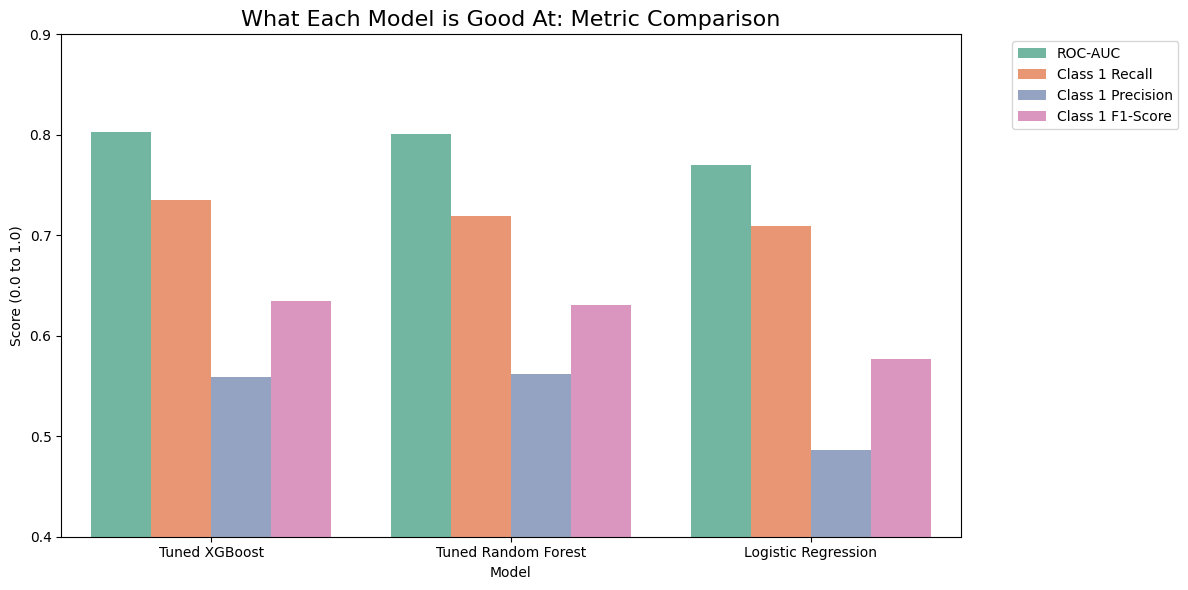

In [102]:
# 4. Create and display the Master Comparison Table
comparison_df = pd.DataFrame(comparison_data).sort_values(by='ROC-AUC', ascending=False)
print("\n=== MASTER MODEL COMPARISON ===")
print(comparison_df.to_markdown(index=False))

# 5. Visualize "What Every Model is Good At"
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=melted_df, palette='Set2')
plt.title('What Each Model is Good At: Metric Comparison', fontsize=16)
plt.ylabel('Score (0.0 to 1.0)')
plt.ylim(0.4, 0.9)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#Most Important Hiring Factors

In [103]:
dict(sorted(zip(rf_random.best_estimator_.feature_names_in_, rf_random.best_estimator_.feature_importances_), key=lambda x: x[1], reverse=True))

{'city_development_index': np.float64(0.32698238309091476),
 'company_size_encoded': np.float64(0.2276884451040336),
 'city_freq': np.float64(0.12126812536427249),
 'experience_encoded': np.float64(0.08205681299107337),
 'training_hours_capped': np.float64(0.0750824281651139),
 'education_level_encoded': np.float64(0.06578540423925425),
 'last_new_job_encoded': np.float64(0.039882291571630105),
 'enrolled_university_encoded': np.float64(0.03468035281168448),
 'relevent_experience_encoded': np.float64(0.02657375666202304)}

#Candidate Ranking System

In [104]:
best_xgb = best_xgb_pipeline
probabilities = best_xgb.predict_proba(X_test)[:, 1]
candidate_ranking = df_test.copy()
candidate_ranking['Probability'] = probabilities

candidate_ranking = candidate_ranking.sort_values(
    by='Probability',
    ascending=False
)

top_10_candidates = candidate_ranking.head(10).copy()

top_10_candidates.insert(
    0,
    'Rank',
    range(1, 11)
)
top_10_candidates['Recommendation'] = 'Recommended'

top_10_candidates[
    [
        'Rank',
        'enrollee_id',
        'education_level',
        'experience',
        'relevent_experience',
        'training_hours',
        'Probability',
        'Recommendation'
    ]
]

,Rank,enrollee_id,education_level,experience,relevent_experience,training_hours,Probability,Recommendation
2003,1,32898,Graduate,1,No relevent experience,11,0.866830,Recommended
2031,2,21968,Graduate,<1,No relevent experience,50,0.859155,Recommended
126,3,24162,Graduate,<1,Has relevent experience,48,0.858647,Recommended
1937,4,181,Graduate,<1,Has relevent experience,300,0.854646,Recommended
878,5,27338,Graduate,11,No relevent experience,103,0.850221,Recommended
1372,6,26993,Graduate,1,No relevent experience,54,0.849099,Recommended
947,7,462,Graduate,5,No relevent experience,46,0.848723,Recommended
465,8,14601,Masters,1,Has relevent experience,14,0.848300,Recommended
1934,9,17450,Graduate,<1,No relevent experience,151,0.847122,Recommended
1720,10,18519,Graduate,4,No relevent experience,53,0.843127,Recommended


#Candidate Predictions

In [105]:
#Final Predictions

X_test = df_test[X_train.columns]



predictions = best_xgb_pipeline.predict(X_test)


probabilities = best_xgb_pipeline.predict_proba(X_test)[:, 1]


submission_df = pd.DataFrame({
    'enrollee_id': df_test['enrollee_id'],
    'target': predictions,
    'flight_risk_probability': probabilities
})



file_name = 'final_candidate_predictions.csv'
submission_df.to_csv(file_name, index=False)

print("--- SUCCESS ---")
print(f"Predictions successfully saved to: {file_name}\n")

display(submission_df.head())

--- SUCCESS ---
Predictions successfully saved to: final_candidate_predictions.csv



,enrollee_id,target,flight_risk_probability
0,32403,0,0.347524
1,9858,1,0.732173
2,31806,1,0.753392
3,27385,0,0.237467
4,27724,0,0.233743


#Save Models

In [106]:
import pickle

best_rf = rf_random.best_estimator_

with open('/content/drive/MyDrive/Project ITI/best_rf_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Model saved successfully!")

Model saved successfully!


In [107]:
with open('/content/drive/MyDrive/Project ITI/best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb_pipeline, f)

print("Tuned XGBoost model saved successfully!")

Tuned XGBoost model saved successfully!


## Exporting Processed Data

In [122]:
processed_train_path = '/content/drive/MyDrive/Project ITI/processed_aug_train.csv'
processed_test_path = '/content/drive/MyDrive/Project ITI/processed_aug_test.csv'

df_train.to_csv(processed_train_path, index=False)
df_test.to_csv(processed_test_path, index=False)

print(f"Processed training data saved to: {processed_train_path}")
print(f"Processed testing data saved to: {processed_test_path}")

Processed training data saved to: /content/drive/MyDrive/Project ITI/processed_aug_train.csv
Processed testing data saved to: /content/drive/MyDrive/Project ITI/processed_aug_test.csv
